# Analiza podatkov s pandas

Povzeto po [https://github.com/matijapretnar/programiranje-1/tree/master/03-knjiznica-pandas](https://github.com/matijapretnar/programiranje-1/tree/master/03-knjiznica-pandas).

[Pandas quick-start guide](http://pandas.pydata.org/pandas-docs/stable/10min.html)  
[Pandas documentation](http://pandas.pydata.org/pandas-docs/stable/)  
[Lecture notes on pandas](../predavanja/analiza-filmov.ipynb)


### Naložimo pandas in podatke

In [84]:
# (desno zgoraj moraš izbrati python emvironments namesto select kernel)
#(play trikotnik levo zgoraj požene posamezno celico)
# naložimo paket
import pandas as pd

# ker bomo delali z velikimi razpredelnicami, povemo, da naj se vedno izpiše le 10 vrstic
pd.set_option("display.max_rows", 10)

# izberemo interaktivni "notebook" stil risanja
%matplotlib inline

# naložimo razpredelnico, s katero bomo delali
FILMI = pd.read_csv("filmi.csv", index_col="id")  #(ni nam všeč prvi stolpec, ki jih oštevilči, zato dodamo še drugi parameter, ki ta stolpec izbriše)

Poglejmo si podatke.

In [85]:
FILMI

,naslov,dolzina,leto,ocena,metascore,glasovi,zasluzek,oznaka,opis
id,,,,,,,,,
4972,The Birth of a Nation,195,1915,6.2,NaN,24890,10000000.0,TV-PG,The Stoneman family finds its friendship with ...
6864,Intolerance,197,1916,7.7,99.0,15670,2180000.0,Passed,The story of a poor young woman separated by p...
9968,Broken Blossoms,90,1919,7.3,NaN,10423,NaN,Not Rated,"A frail waif, abused by her brutal boxer fathe..."
10323,The Cabinet of Dr. Caligari,67,1920,8.0,NaN,64133,NaN,Not Rated,"Hypnotist Dr. Caligari uses a somnambulist, Ce..."
12349,The Kid,68,1921,8.3,NaN,126513,5450000.0,Passed,"The Tramp cares for an abandoned child, but ev..."
...,...,...,...,...,...,...,...,...,...
18568902,Kaun Pravin Tambe?,134,2022,8.4,NaN,10163,NaN,NaN,An indian cricketer who shows persistence and ...
18689424,Batman v Superman: Dawn of Justice - Ultimate ...,182,2016,7.1,NaN,57662,NaN,R,Batman is manipulated by Lex Luthor to fear Su...
18968540,Incantation,110,2022,6.2,NaN,12366,NaN,TV-MA,"Six years ago, Li Ronan was cursed after break..."


## Proučevanje podatkov

Razvrstite podatke po ocenah.

In [86]:
FILMI.sort_values("ocena", ascending=False, inplace=True)  #(ascending pomeni naraščajoče, sort_values ustvari novo tabelo, origanalna ostane enaka: če želimo da popravi originalno, damo 3. parameter inplace)
FILMI

,naslov,dolzina,leto,ocena,metascore,glasovi,zasluzek,oznaka,opis
id,,,,,,,,,
15327088,Kantara,148,2022,9.4,NaN,33294,NaN,NaN,It involves culture of Kambla and Bhootha Kola...
111161,The Shawshank Redemption,142,1994,9.3,81.0,2651625,28341469.0,R,Two imprisoned men bond over a number of years...
68646,The Godfather,175,1972,9.2,100.0,1838099,134966411.0,R,The aging patriarch of an organized crime dyna...
252487,The Chaos Class,87,1975,9.2,NaN,40747,NaN,NaN,"Lazy, uneducated students share a very close b..."
71562,The Godfather Part II,202,1974,9.0,90.0,1259498,57300000.0,R,The early life and career of Vito Corleone in ...
...,...,...,...,...,...,...,...,...,...
6038600,Smolensk,120,2016,1.2,NaN,39704,NaN,NaN,An inspired story of people affected by the tr...
421051,Daniel the Wizard,81,2004,1.2,NaN,14413,NaN,Not Rated,"Evil assassins want to kill Daniel Kublbock, t..."
7886848,Sadak 2,133,2020,1.1,NaN,95865,NaN,TV-MA,"The film picks up where Sadak left off, revolv..."


Poberite stolpec ocen.

In [87]:
ocene = FILMI["ocena"]
ocene

id
15327088    9.4
111161      9.3
68646       9.2
252487      9.2
71562       9.0
           ... 
6038600     1.2
421051      1.2
7886848     1.1
5988370     1.0
7221896     1.0
Name: ocena, Length: 9999, dtype: float64

Ukaza `filmi['ocena']` in `filmi[['ocena']]` sta različna:

In [88]:
print(type(FILMI['ocena']))  #(uporabimo, ko želimo noter dodati še kak stolpec, vedno samo 1 stolpec)
print(type(FILMI[['ocena']]))  #(to drugače oblikuje, bolj kot tabela - boljši, ker so na njem definirane metode, lahko več stolpcev)

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


Stolpci objekta `DataFrame` so tipa `Series`. Z enojnimi oklepaji poberemo `Series`, z dvojnimi oklepaji pa `DataFrame` podtabelo. Večina operacij (grouping, joining, plotting,  filtering, ...) deluje na `DataFrame`. 

Tip `Series` se uporablja ko želimo npr. dodati stolpec.

Zaokrožite stolpec ocen z funkcijo `round()` in dobljeni `Series` shranite v `zaokrozena_ocena`.

In [89]:
zaokrozena_ocena = ocene.apply(round)
zaokrozena_ocena

id
15327088    9
111161      9
68646       9
252487      9
71562       9
           ..
6038600     1
421051      1
7886848     1
5988370     1
7221896     1
Name: ocena, Length: 9999, dtype: int64

Dodajte zaokrožene vrednosti v podatke.

In [90]:
FILMI["zaokrožena ocena"] = zaokrozena_ocena
FILMI

,naslov,dolzina,leto,ocena,metascore,glasovi,zasluzek,oznaka,opis,zaokrožena ocena
id,,,,,,,,,,
15327088,Kantara,148,2022,9.4,NaN,33294,NaN,NaN,It involves culture of Kambla and Bhootha Kola...,9
111161,The Shawshank Redemption,142,1994,9.3,81.0,2651625,28341469.0,R,Two imprisoned men bond over a number of years...,9
68646,The Godfather,175,1972,9.2,100.0,1838099,134966411.0,R,The aging patriarch of an organized crime dyna...,9
252487,The Chaos Class,87,1975,9.2,NaN,40747,NaN,NaN,"Lazy, uneducated students share a very close b...",9
71562,The Godfather Part II,202,1974,9.0,90.0,1259498,57300000.0,R,The early life and career of Vito Corleone in ...,9
...,...,...,...,...,...,...,...,...,...,...
6038600,Smolensk,120,2016,1.2,NaN,39704,NaN,NaN,An inspired story of people affected by the tr...,1
421051,Daniel the Wizard,81,2004,1.2,NaN,14413,NaN,Not Rated,"Evil assassins want to kill Daniel Kublbock, t...",1
7886848,Sadak 2,133,2020,1.1,NaN,95865,NaN,TV-MA,"The film picks up where Sadak left off, revolv...",1


Odstranite novo dodani stolpec z metodo `.drop()` z podanim `columns = ` argumentom.

In [91]:
FILMI.drop(columns=["zaokrožena ocena"], inplace=True)  #(če to poženeš več kot enkrat, ti ne bo pustilo, ker si že pej zbrisal)
FILMI

,naslov,dolzina,leto,ocena,metascore,glasovi,zasluzek,oznaka,opis
id,,,,,,,,,
15327088,Kantara,148,2022,9.4,NaN,33294,NaN,NaN,It involves culture of Kambla and Bhootha Kola...
111161,The Shawshank Redemption,142,1994,9.3,81.0,2651625,28341469.0,R,Two imprisoned men bond over a number of years...
68646,The Godfather,175,1972,9.2,100.0,1838099,134966411.0,R,The aging patriarch of an organized crime dyna...
252487,The Chaos Class,87,1975,9.2,NaN,40747,NaN,NaN,"Lazy, uneducated students share a very close b..."
71562,The Godfather Part II,202,1974,9.0,90.0,1259498,57300000.0,R,The early life and career of Vito Corleone in ...
...,...,...,...,...,...,...,...,...,...
6038600,Smolensk,120,2016,1.2,NaN,39704,NaN,NaN,An inspired story of people affected by the tr...
421051,Daniel the Wizard,81,2004,1.2,NaN,14413,NaN,Not Rated,"Evil assassins want to kill Daniel Kublbock, t..."
7886848,Sadak 2,133,2020,1.1,NaN,95865,NaN,TV-MA,"The film picks up where Sadak left off, revolv..."


### Opomba: slice
Izbira podtabele ustvari t.i. "rezino" oz. "slice".
Slice ni kopija tabele, temveč zgolj sklic na izvorno tabelo,
in je zato ne moremo spreminjati.
Če želimo kopijo, uporabimo metodo `.copy()` na rezini, ki jo nato lahko spreminjamo.


Izberite podtabelo s stolpci `naslov`, `leto`, in `glasovi`, kateri nato dodate solpec z zaokroženimi ocenami.

In [92]:
poenostavljena_tabela = FILMI[["naslov", "leto", "glasovi"]].copy()  #(če ne bi bilo .copy() ne bi mogli dodat stolpca)
poenostavljena_tabela["zaokrožena ocena"] = zaokrozena_ocena
poenostavljena_tabela

,naslov,leto,glasovi,zaokrožena ocena
id,,,,
15327088,Kantara,2022,33294,9
111161,The Shawshank Redemption,1994,2651625,9
68646,The Godfather,1972,1838099,9
252487,The Chaos Class,1975,40747,9
71562,The Godfather Part II,1974,1259498,9
...,...,...,...,...
6038600,Smolensk,2016,39704,1
421051,Daniel the Wizard,2004,14413,1
7886848,Sadak 2,2020,95865,1


### Filtracija

Ustvarite filter, ki izbere filme, ki so izšli pred 1930, in filter za filme po 2017.
Združite ju za izbor filmov, ki so izšli pred 1930 ali po 2017.

In [93]:
filter_pred_1930 = FILMI["leto"] < 1930
filter_po_2017 = FILMI["leto"] > 2017
filter_skrajni = filter_pred_1930 | filter_po_2017  #(ni definirana operacija or na series, zato pa je definirana operacija |)
# ( filter_skrajni2 = (FILMI["leto"] < 1930) | (FILMI["leto"] > 2017) - nujno rabiš oklepaje, ker ima | manjšo prioriteto kot <>)
FILMI[filter_skrajni]


,naslov,dolzina,leto,ocena,metascore,glasovi,zasluzek,oznaka,opis
id,,,,,,,,,
15327088,Kantara,148,2022,9.4,NaN,33294,NaN,NaN,It involves culture of Kambla and Bhootha Kola...
16492678,Demon Slayer: Kimetsu no Yaiba - Tsuzumi Mansi...,87,2021,9.0,NaN,12634,NaN,NaN,Tanjiro ventures to the south-southeast where ...
9263550,Rocketry: The Nambi Effect,157,2022,8.9,NaN,47460,NaN,NaN,Based on the life of Indian Space Research Org...
7466810,777 Charlie,164,2022,8.9,NaN,26856,NaN,NaN,Dharma is stuck in a rut with his negative and...
15097216,Jai Bhim,164,2021,8.9,NaN,199511,NaN,TV-MA,When a tribal man is arrested for a case of al...
...,...,...,...,...,...,...,...,...,...
5013984,Gully,84,2019,1.9,NaN,18826,NaN,R,"Three teens living in LA, all victims of extre..."
7431594,Race 3,160,2018,1.9,NaN,46781,1690861.0,Not Rated,Relationships and loyalties of a criminal fami...
8402090,Cumali Ceber 2,100,2018,1.7,NaN,10791,NaN,NaN,Cumali Ceber learns about the demolition of th...


Definirajte funkcijo, ki preveri ali niz vsebuje kvečjemu dve besedi. Nato s pomočjo `.apply()` izberite vse filme z imeni, krajšimi od dveh besed in oceno nad 8.

In [94]:
def najvec_dve_besedi(niz):
    return len(niz.split()) <= 2  #(če ne damo parametra v split, šteje vse zaporedne presledke kot enega)

filter_kratki_sladki = FILMI["naslov"].apply(najvec_dve_besedi) & (FILMI["ocena"] > 8)  #(namesto and imamo &)
FILMI[filter_kratki_sladki]

,naslov,dolzina,leto,ocena,metascore,glasovi,zasluzek,oznaka,opis
id,,,,,,,,,
15327088,Kantara,148,2022,9.4,NaN,33294,NaN,NaN,It involves culture of Kambla and Bhootha Kola...
68646,The Godfather,175,1972,9.2,100.0,1838099,134966411.0,R,The aging patriarch of an organized crime dyna...
108052,Schindler's List,195,1993,9.0,94.0,1343684,96898818.0,R,"In German-occupied Poland during World War II,..."
5354160,Mirror Game,147,2016,9.0,NaN,27034,NaN,NaN,Ayna is an actor and the prison is his stage. ...
253779,Süt Kardesler,80,1976,8.9,NaN,20071,NaN,NaN,"Saban, Ramazan and Bayram are sailors in an Ot..."
...,...,...,...,...,...,...,...,...,...
2338151,PK,153,2014,8.1,NaN,187685,10616104.0,Not Rated,An alien on Earth loses the only device he can...
88247,The Terminator,107,1984,8.1,84.0,859720,38400000.0,R,A human soldier is sent from 2029 to 1984 to s...
18773,The Circus,72,1928,8.1,90.0,33948,NaN,Passed,The Tramp finds work and the girl of his dream...


### Manjkajoče vrednosti

Koliko filmov ima neznan zaslužek? Koliko filmov ima znan zaslužek?

In [95]:
# (NaN je oznaka, da tam ni podatka)
filter_manjka_zasluzek = FILMI["zasluzek"].isna()  #(.isna je metoda, s katero preverimo, če podatka ni)
filter_znan_zasluzek = FILMI["zasluzek"].notna()  #(če podatek je)
# (filter_znan_zasluzek2 = ~filter_manjka_zasluzek - ~ pomeni negacija)

stevilo_manjka_zasluzek = sum(filter_manjka_zasluzek)
stevilo_znan_zasluzek = sum(filter_znan_zasluzek)
print(stevilo_manjka_zasluzek, stevilo_znan_zasluzek)

2741 7258


### Histogrami

Združite filme po (zaokroženih) ocenah in jih preštejte.

In [96]:
po_ocenah = poenostavljena_tabela.groupby(by=["zaokrožena ocena"]).size()  #(združi vse podatke, ki imajo enako zaokroženo oceno, če ne pokličemo še kakšne metode, je to neuporabno)
po_ocenah

zaokrožena ocena
1       7
2      33
3      55
4     223
5     856
6    3274
7    3554
8    1932
9      65
dtype: int64

Naredite stolpični diagram teh podatkov.

<Axes: xlabel='zaokrožena ocena'>

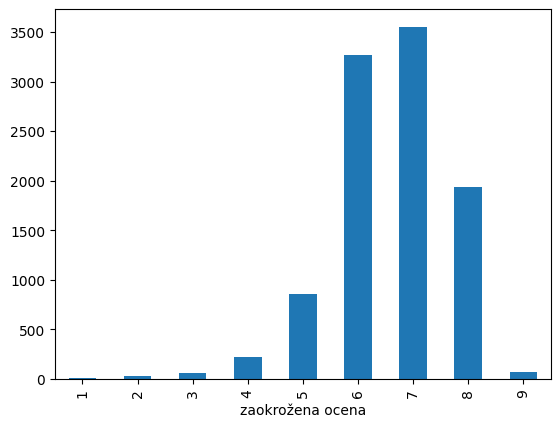

In [97]:
po_ocenah.plot.bar()

Tabele imajo metodo `.hist()`, ki omogoča izgradnjo histogramov za stolpce. Uporabite to metodo za prikaz poenostavljenih podatkov.

array([[<Axes: title={'center': 'leto'}>,
        <Axes: title={'center': 'glasovi'}>],
       [<Axes: title={'center': 'zaokrožena ocena'}>, <Axes: >]],
      dtype=object)

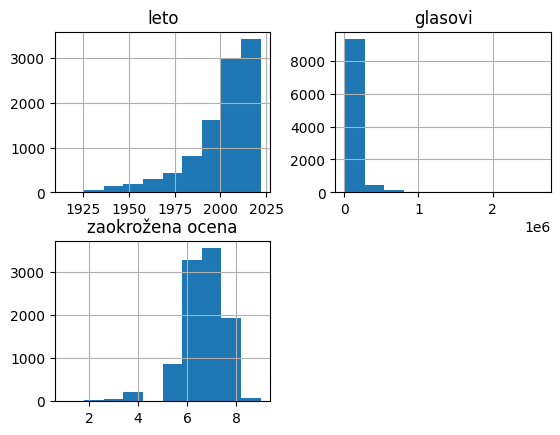

In [98]:
poenostavljena_tabela.hist()  #(sam izbere intervale)

### Izris povprečne dolžine filma glede na leto

<Axes: xlabel='leto', ylabel='Povprečna dolžina v minutah'>

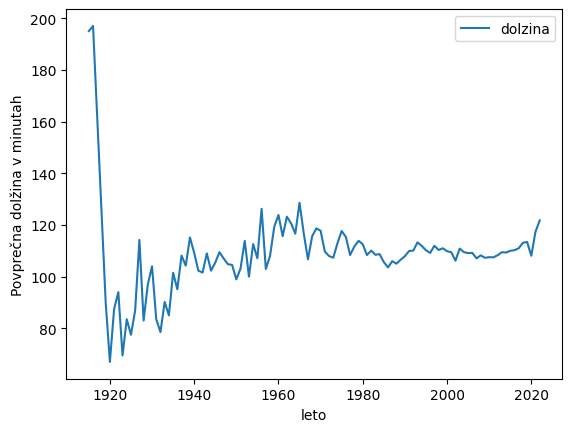

In [99]:
FILMI[["leto", "dolzina"]].groupby(by=["leto"]).mean().plot(ylabel="Povprečna dolžina v minutah")  #(na rabiš pisat po katerem stolpcu, ker smo po letu grupirali, tako da ostane samo dolžina)

### Izris skupnega zasluzka za posamezno leto

<Axes: xlabel='leto'>

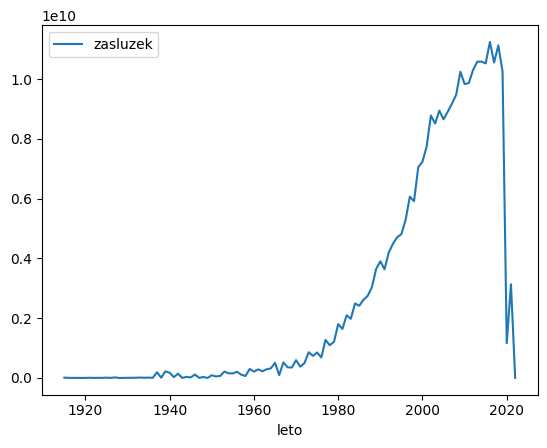

In [101]:
FILMI[["leto", "zasluzek"]].groupby(by=["leto"]).sum().plot()